# All Imports

In [19]:
# Imports
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn.functional as F
from collections import Counter


# Custom Imports
root_dir = Path('.').resolve().parent
src_path = str(root_dir / "src")

if src_path not in sys.path :
    sys.path.append(src_path)

from model_explainability import (test_nodes, explaination_gnn, explainer)
from model_train import (model, data)
from feature_engineering import (predicate_to_id, edge_type)

# Single Test Node Evaluate & Visulize
### Local Explaination

In [3]:
test_node = test_nodes[0]
print("Test Node : ", test_node)

Test Node :  tensor(340)


In [4]:
# Explore Explainations

print(explaination_gnn)
print(explaination_gnn.edge_mask.max())

Explanation(node_mask=[2835, 2835], edge_mask=[20338], prediction=[2835, 5], target=[2835], index=[1], x=[2835, 2835], edge_index=[2, 20338])
tensor(0.0814)


In [5]:
# Find out Top Edges
top_edges = explaination_gnn.edge_mask.topk(10)

# Extract indices from top_edges
important_edge_indices = top_edges.indices


Counter({'isAbout': 7, 'publishes': 2, 'publication': 1})


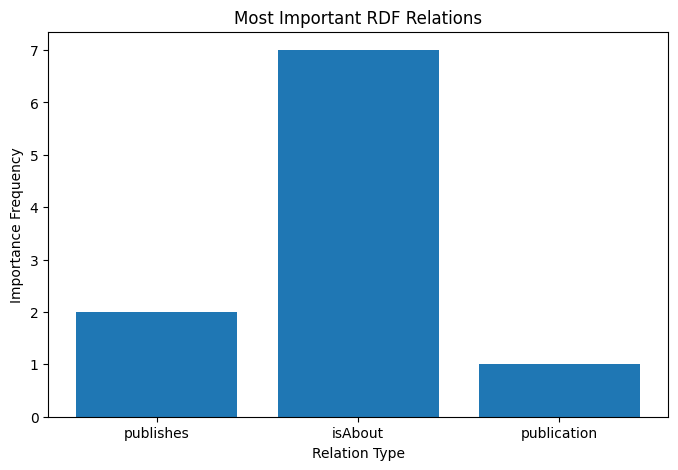

In [6]:
# Important Relation Frequency Plot

important_relations = []
# Create reverse mapping for relations
id_to_relation = {v: k for k, v in predicate_to_id.items()}

for idx in important_edge_indices:

    idx = idx.item()
    rel_id = edge_type[idx].item()
    relation = id_to_relation[rel_id]
    clean_relation = relation.split("#")[-1]
    important_relations.append(clean_relation)

relation_counts = Counter(important_relations)
print(relation_counts)


# Visulisation (Bar Plot)
relations = list(relation_counts.keys())
counts = list(relation_counts.values())

plt.figure(figsize=(8,5))
plt.bar(relations, counts)
plt.xlabel("Relation Type")
plt.ylabel("Importance Frequency")
plt.title("Most Important RDF Relations")
plt.show()

# Multipal Nodes Evaluation & Visulisation
### Global Explaination

In [9]:
# test_nodes = labeled_nodes[:5]
# print(test_nodes)

all_relation_lists = []

# Loop throw the test nodes
for node in test_nodes:

    print("Explaining Node:", node)
    print("-------")

    explanation = explainer(

        x=data.x,
        edge_index=data.edge_index,
        index=int(node)
    )

    important_edges = explanation.edge_mask.topk(20).indices

    relations = []

    for idx in important_edges:

        idx = idx.item()
        rel_id = edge_type[idx].item()
        relation = id_to_relation[rel_id]
        clean_relation = relation.split("#")[-1]
        relations.append(clean_relation)
    # print(relations)
    all_relation_lists.append(relations)


Explaining Node: tensor(249)
-------
Explaining Node: tensor(758)
-------
Explaining Node: tensor(2321)
-------
Explaining Node: tensor(478)
-------
Explaining Node: tensor(1127)
-------
Explaining Node: tensor(228)
-------
Explaining Node: tensor(2030)
-------
Explaining Node: tensor(2747)
-------
Explaining Node: tensor(1843)
-------
Explaining Node: tensor(2341)
-------
Explaining Node: tensor(339)
-------
Explaining Node: tensor(2457)
-------
Explaining Node: tensor(678)
-------
Explaining Node: tensor(2015)
-------
Explaining Node: tensor(179)
-------
Explaining Node: tensor(1847)
-------
Explaining Node: tensor(1893)
-------
Explaining Node: tensor(1424)
-------
Explaining Node: tensor(114)
-------
Explaining Node: tensor(1895)
-------
Explaining Node: tensor(238)
-------
Explaining Node: tensor(1125)
-------
Explaining Node: tensor(1009)
-------
Explaining Node: tensor(2671)
-------
Explaining Node: tensor(2680)
-------
Explaining Node: tensor(2635)
-------
Explaining Node: tens

Counter({'isAbout': 251, 'publication': 175, 'publishes': 63, 'hasProject': 55, 'author': 37, 'carriedOutBy': 33, 'dealtWithIn': 27, 'type': 21, 'worksAtProject': 13, 'finances': 10, 'projectInfo': 9, 'subClassOf': 9, 'isWorkedOnBy': 6, 'carriesOut': 6, 'member': 4, 'editor': 1})


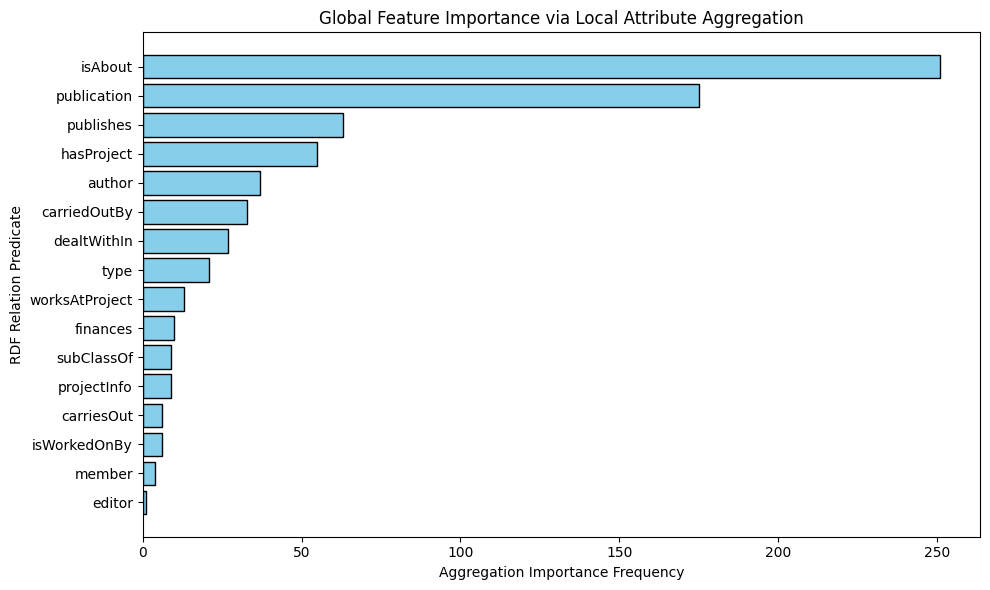

In [17]:
# Combine All Relations
all_relations = []

for relation_list in all_relation_lists:
    all_relations.extend(relation_list)

relation_counter = Counter(all_relations)
print(relation_counter)


# Visulisation
relations = list(relation_counter.keys())
counts = list(relation_counter.values())

# Sort from most frequent to least frequent
sorted_relation_counts = sorted(relation_counter.items(), key=lambda x: x[1], reverse=False) # False puts largest at top in bar
relations = [item[0] for item in sorted_relation_counts]
counts = [item[1] for item in sorted_relation_counts]

plt.figure(figsize=(10, 6))
plt.barh(relations, counts, color='skyblue', edgecolor='black')
plt.xlabel("Aggregation Importance Frequency")
plt.ylabel("RDF Relation Predicate")
plt.title("Global Feature Importance via Local Attribute Aggregation")
plt.tight_layout()  # Prevents labels from clipping
plt.show()

# Faithfulness Check

If we remove those important edges, does prediction change ?

Tasks :-

1. Get original prediction

2. Remove important edges

3. Run model again

4. Compare prediction confidence

In [9]:
# RESET EXPLAIN MODE FOR SAFETY
model.conv1.explain = False
model.conv2.explain = False
model.eval()

# --- SET UP EVALUATION SUBSET ---
# Select the first 10 nodes for the batch summary analysis
eval_nodes = test_nodes[:10]  

confidence_drops = []
label_flips = 0
total_nodes_evaluated = 0

print(f"Running GNNExplainer Faithfulness batch check over {len(eval_nodes)} nodes...\n")

Running GNNExplainer Faithfulness batch check over 10 nodes...



In [10]:
for node_id in eval_nodes:
    node_idx = int(node_id)
    
    try:
        # 1. GET ORIGINAL PREDICTION & CONFIDENCE
        with torch.no_grad():
            orig_out = model(data.x, 
                             data.edge_index, 
                             data.edge_type)
        
        orig_prediction = orig_out[node_idx]
        orig_probs = F.softmax(orig_prediction, dim=0)
        orig_class = torch.argmax(orig_probs).item()
        orig_confidence = orig_probs[orig_class].item()
        
        # 2. GENERATE GNNEXPLAINER ATTRIBUTIONS FOR THIS NODE
        # explainer.algorithm.epochs = 30 
        explanation_gnn = explainer(x=data.x, 
                                    edge_index=data.edge_index, 
                                    index=node_idx)
        
        # Extract top 50 important edges
        important_edges = explanation_gnn.edge_mask.topk(50).indices
        
        # 3. CREATE GRAPH PERTURBATION MASK
        num_edges = data.edge_index.shape[1]
        keep_mask = torch.ones(num_edges, dtype=torch.bool)
        keep_mask[important_edges] = False
        
        new_edge_index = data.edge_index[:, keep_mask]
        new_edge_type = data.edge_type[keep_mask]
        
        # 4. RUN MODEL ON MODIFIED GRAPH STRUCTURE
        with torch.no_grad():
            modified_out = model(data.x, new_edge_index, new_edge_type)
            
        modified_prediction = modified_out[node_idx]
        modified_probs = F.softmax(modified_prediction, dim=0)
        
        # Track confidence drop for the original predicted class
        new_confidence = modified_probs[orig_class].item()
        conf_drop = orig_confidence - new_confidence
        confidence_drops.append(conf_drop)
        
        # Check if the overall prediction label flipped
        new_class = torch.argmax(modified_probs).item()
        if orig_class != new_class:
            label_flips += 1
            
        total_nodes_evaluated += 1
        
    except Exception as e:
        print(f"Skipping Node {node_idx} due to structural limits: {e}")

In [11]:
# --- 5. COMPUTE FINAL AGGREGATIONS ---
if total_nodes_evaluated > 0:
    avg_conf_drop = sum(confidence_drops) / total_nodes_evaluated
    flip_rate = (label_flips / total_nodes_evaluated) * 100
else:
    avg_conf_drop = 0.0
    flip_rate = 0.0

In [13]:
# --- PRINT SUMMARY REPORT ---
print("=" * 50)
print(f"{'FINAL FAITHFULNESS SUMMARY METRICS':^50}")
print("=" * 50)
print(f"Total Nodes Evaluated                 : {total_nodes_evaluated}")
print(f"Average Confidence Drop (Delta Conf) : {avg_conf_drop:.4f} ({avg_conf_drop * 100:.1f}%)")
print(f"Prediction Label Flip Rate            : {flip_rate:.1f}%")
print("=" * 50)

        FINAL FAITHFULNESS SUMMARY METRICS        
Total Nodes Evaluated                 : 10
Average Confidence Drop (Delta Conf) : 0.0038 (0.4%)
Prediction Label Flip Rate            : 20.0%


# Overall Performance

In [14]:
# RESET EXPLAIN MODE FOR SAFETY
model.conv1.explain = False
model.conv2.explain = False
model.eval()

# --- SET UP EVALUATION SUBSET ---
eval_nodes = test_nodes[:10]  

confidence_drops = []
sparsities = []
execution_times = []
label_flips = 0
total_nodes_evaluated = 0

print(f"Calculating Overall Performance Metrics for GNNExplainer over {len(eval_nodes)} nodes...\n")

Calculating Overall Performance Metrics for GNNExplainer over 10 nodes...



In [17]:
for node_id in eval_nodes:
    node_idx = int(node_id)
    
    try:
        # 1. TIME GENERATION OF GNNEXPLAINER ATTRIBUTIONS
        start_time = time.perf_counter()
        explanation_gnn = explainer(x=data.x, edge_index=data.edge_index, index=node_idx)
        end_time = time.perf_counter()
        
        # Calculate and record execution time
        node_time = end_time - start_time
        execution_times.append(node_time)
        
        # 2. CALCULATE SUBGRAPH SPARSITY
        # Count how many total computational edges are present in this node's neighborhood
        raw_mask = explanation_gnn.edge_mask
        total_neighborhood_edges = raw_mask.shape[0]
        
        # Define your explanation subgraph size
        k = 20
        
        # Sparsity formula: 1 - (K / Total Edges)
        if total_neighborhood_edges > k:
            node_sparsity = 1.0 - (k / total_neighborhood_edges)
        else:
            node_sparsity = 0.0 # If neighborhood is already tiny, sparsity is 0
        sparsities.append(node_sparsity)
        
        # 3. GET ORIGINAL PREDICTION & CONFIDENCE
        with torch.no_grad():
            orig_out = model(data.x, data.edge_index, data.edge_type)
        orig_probs = F.softmax(orig_out[node_idx], dim=0)
        orig_class = torch.argmax(orig_probs).item()
        orig_confidence = orig_probs[orig_class].item()
        
        # 4. REMOVE IMPORTANT EDGES AND PERTURB GRAPH
        top_edges = raw_mask.topk(k).indices
        num_edges = data.edge_index.shape[1]
        keep_mask = torch.ones(num_edges, dtype=torch.bool)
        keep_mask[top_edges] = False
        
        new_edge_index = data.edge_index[:, keep_mask]
        new_edge_type = data.edge_type[keep_mask]
        
        # 5. RUN MODEL ON PERTURBED GRAPH
        with torch.no_grad():
            modified_out = model(data.x, new_edge_index, new_edge_type)
        mod_probs = F.softmax(modified_out[node_idx], dim=0)
        
        # Track confidence drop and label flips
        new_confidence = mod_probs[orig_class].item()
        conf_drop = orig_confidence - new_confidence
        confidence_drops.append(conf_drop)
        
        new_class = torch.argmax(mod_probs).item()
        if orig_class != new_class:
            label_flips += 1
            
        total_nodes_evaluated += 1
        
    except Exception as e:
        print(f"Skipping Node {node_idx} due to calculation error: {e}")

In [20]:
# --- 6. COMPUTE FINAL SYSTEM METRICS ---
if total_nodes_evaluated > 0:
    avg_conf_drop = np.mean(confidence_drops)
    avg_sparsity = np.mean(sparsities)
    avg_time = np.mean(execution_times)
    flip_rate = (label_flips / total_nodes_evaluated) * 100
else:
    avg_conf_drop, avg_sparsity, avg_time, flip_rate = 0.0, 0.0, 0.0, 0.0

In [26]:
# --- PRINT PERFORMANCE REPORT ---
print("=" * 60)
print(f"{'GNNEXPLAINER OVERALL PERFORMANCE REPORT':^60}")
print("=" * 60)
print(f"Total Nodes Evaluated                   : {total_nodes_evaluated}")
print(f"Average Execution Time                  : {avg_time:.4f} seconds / node")
print(f"Average Sparsity (K={k})                 : {avg_sparsity * 100:.2f}%")
print(f"Average Confidence Drop ($\Delta$ Conf) : {avg_conf_drop:.4f} ({avg_conf_drop * 100:.1f}%)")
print(f"Prediction Label Flip Rate              : {flip_rate:.1f}%")
print("=" * 60)

          GNNEXPLAINER OVERALL PERFORMANCE REPORT           
Total Nodes Evaluated                   : 10
Average Execution Time                  : 27.3934 seconds / node
Average Sparsity (K=20)                 : 99.90%
Average Confidence Drop ($\Delta$ Conf) : 0.0021 (0.2%)
Prediction Label Flip Rate              : 20.0%


<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
C:\Users\zalak\AppData\Local\Temp\ipykernel_15624\2355778748.py:8: SyntaxWarning: invalid escape sequence '\D'
  print(f"Average Confidence Drop ($\Delta$ Conf) : {avg_conf_drop:.4f} ({avg_conf_drop * 100:.1f}%)")
